<a href="https://colab.research.google.com/github/ishikadubey1105/HACK-O-WEEK-SEM-V/blob/main/housing_week1_week2_foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# California Housing — Week 1: Foundations

**Dataset:** `housing.csv` (California housing, 20,640 rows)

Covers the Week 1 foundations:

1. Data loading
2. Data cleaning
3. Python OOP essentials
4. NumPy vectorized operations
5. Pandas cleaning / merging / groupby
6. Matplotlib & Seaborn visualization

> **Colab note:** Upload `housing.csv` before running.


In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)
np.random.seed(42)


## 1. Data Loading

In [4]:
DATA_PATH = "housing.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded dataset: {df.shape}")
else:
    raise FileNotFoundError(f"Upload {DATA_PATH} to this notebook's working directory first.")

df.head()


Loaded dataset: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Initial Exploration

In [5]:
print("Shape:", df.shape)
df.info()


Shape: (20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [7]:
df["ocean_proximity"].value_counts()


,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


## 3. Data Cleaning (Pandas)

`total_bedrooms` has missing values — fill with the median rather than
dropping rows, so we don't lose otherwise-complete records.


In [8]:
df.isna().sum()[df.isna().sum() > 0]


,0
total_bedrooms,207


In [9]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows")
print("Remaining missing values:", df.isna().sum().sum())


Dropped 0 duplicate rows
Remaining missing values: 0


## 4. Python OOP Essentials

- **Encapsulation** — the DataFrame is stored privately, accessed via properties/methods.
- **Inheritance** — `AdvancedHousingAnalyzer` extends `HousingAnalyzer`.
- **Polymorphism** — both implement `summary()`, the subclass overrides it.
- **Class/static methods** — an alternate constructor and a stateless helper.


In [10]:
class HousingAnalyzer:
    """Encapsulates basic analysis over the housing dataset."""

    def __init__(self, data: pd.DataFrame, target_col: str = "median_house_value"):
        self._data = data.copy()
        self._target_col = target_col

    @property
    def data(self) -> pd.DataFrame:
        return self._data

    @property
    def average_value(self) -> float:
        return round(self._data[self._target_col].mean(), 2)

    def most_expensive(self, n: int = 5) -> pd.DataFrame:
        return self._data.nlargest(n, self._target_col)

    def summary(self) -> dict:
        return {
            "n_districts": len(self._data),
            "average_value": self.average_value,
            "value_std": round(self._data[self._target_col].std(), 2),
        }

    @staticmethod
    def price_to_tier(value: float) -> str:
        """Stateless helper — doesn't need an instance."""
        if value >= 400_000: return "Luxury"
        if value >= 250_000: return "High"
        if value >= 150_000: return "Mid"
        return "Affordable"

    @classmethod
    def from_csv(cls, path: str, target_col: str = "median_house_value"):
        return cls(pd.read_csv(path), target_col=target_col)


class AdvancedHousingAnalyzer(HousingAnalyzer):
    """Adds correlation-based insights (inheritance)."""

    def __init__(self, data: pd.DataFrame, target_col: str = "median_house_value"):
        super().__init__(data, target_col)

    def strongest_correlate(self) -> tuple:
        numeric = self._data.select_dtypes(include=[np.number])
        corr = numeric.corr()[self._target_col].drop(self._target_col)
        top_feature = corr.abs().idxmax()
        return top_feature, round(corr[top_feature], 3)

    def summary(self) -> dict:                     # polymorphism: overridden method
        base_summary = super().summary()
        feature, corr_value = self.strongest_correlate()
        base_summary["strongest_correlate"] = feature
        base_summary["correlation"] = corr_value
        return base_summary


analyzer = AdvancedHousingAnalyzer(df)
analyzer.summary()


{'n_districts': 20640,
 'average_value': np.float64(206855.82),
 'value_std': 115395.62,
 'strongest_correlate': 'median_income',
 'correlation': np.float64(0.688)}

In [11]:
df["price_tier"] = df["median_house_value"].apply(HousingAnalyzer.price_to_tier)
df[["median_house_value", "price_tier"]].head()


,median_house_value,price_tier
0,452600.0,Luxury
1,358500.0,High
2,352100.0,High
3,341300.0,High
4,342200.0,High


## 5. NumPy Vectorized Operations

In [12]:
rooms_arr = df["total_rooms"].to_numpy()
households_arr = df["households"].to_numpy()
population_arr = df["population"].to_numpy()
bedrooms_arr = df["total_bedrooms"].to_numpy()
income_arr = df["median_income"].to_numpy()
value_arr = df["median_house_value"].to_numpy()

# Vectorized feature engineering (no Python loops)
df["rooms_per_household"] = rooms_arr / households_arr
df["bedrooms_per_room"] = bedrooms_arr / rooms_arr
df["population_per_household"] = population_arr / households_arr

# Z-score normalization
def zscore(arr: np.ndarray) -> np.ndarray:
    return (arr - arr.mean()) / arr.std()

df["income_z"] = zscore(income_arr)

# Vectorized boolean masking
high_income_mask = income_arr >= np.median(income_arr)
print("Districts with above-median income:", high_income_mask.sum())

# np.select — multi-condition vectorized bucketing
conditions = [income_arr < 2, (income_arr >= 2) & (income_arr < 5), income_arr >= 5]
choices = ["Low", "Medium", "High"]
df["income_bucket"] = np.select(conditions, choices, default="Unknown")

# Vectorized correlation matrix
corr_matrix = np.corrcoef(np.vstack([income_arr, rooms_arr, value_arr]))
print("Correlation matrix (income, rooms, value):\n", np.round(corr_matrix, 3))

df[["rooms_per_household", "bedrooms_per_room", "population_per_household", "income_bucket"]].head()


Districts with above-median income: 10320
Correlation matrix (income, rooms, value):
 [[1.    0.198 0.688]
 [0.198 1.    0.134]
 [0.688 0.134 1.   ]]


,rooms_per_household,bedrooms_per_room,population_per_household,income_bucket
0,6.984127,0.146591,2.555556,High
1,6.238137,0.155797,2.109842,High
2,8.288136,0.129516,2.802260,High
3,5.817352,0.184458,2.547945,High
4,6.281853,0.172096,2.181467,Medium


## 6. Pandas Cleaning / Merging / GroupBy

In [13]:
# Supplementary lookup dataframe: ocean_proximity -> descriptive region label
region_lookup = pd.DataFrame({
    "ocean_proximity": ["NEAR BAY", "<1H OCEAN", "INLAND", "NEAR OCEAN", "ISLAND"],
    "region_label": ["Bay Area", "Coastal (close)", "Inland", "Coastal (near ocean)", "Island"],
})

df = df.merge(region_lookup, on="ocean_proximity", how="left")
df[["ocean_proximity", "region_label", "median_house_value"]].head()


,ocean_proximity,region_label,median_house_value
0,NEAR BAY,Bay Area,452600.0
1,NEAR BAY,Bay Area,358500.0
2,NEAR BAY,Bay Area,352100.0
3,NEAR BAY,Bay Area,341300.0
4,NEAR BAY,Bay Area,342200.0


In [14]:
# GroupBy: average value by income bucket
income_summary = (
    df.groupby("income_bucket")["median_house_value"]
      .agg(["mean", "median", "std", "count"])
      .round(2)
      .reindex(["Low", "Medium", "High"])
)
income_summary


,mean,median,std,count
income_bucket,,,,
Low,112512.67,93300.0,71749.44,2439
Medium,183692.56,165500.0,90213.17,13692
High,328225.14,311600.0,110840.33,4509


In [15]:
# GroupBy: multiple aggregations by region
region_summary = (
    df.groupby("region_label")
      .agg(
          avg_value=("median_house_value", "mean"),
          avg_income=("median_income", "mean"),
          avg_rooms_per_household=("rooms_per_household", "mean"),
          n_districts=("median_house_value", "count"),
      )
      .round(2)
      .sort_values("avg_value", ascending=False)
)
region_summary


,avg_value,avg_income,avg_rooms_per_household,n_districts
region_label,,,,
Island,380440.00,2.74,5.66,5
Bay Area,259212.31,4.17,5.22,2290
Coastal (near ocean),249433.98,4.01,5.21,2658
Coastal (close),240084.29,4.23,5.15,9136
Inland,124805.39,3.21,5.98,6551


In [16]:
# GroupBy: price tier distribution by region (crosstab-style)
tier_by_region = (
    df.groupby(["region_label", "price_tier"])
      .size()
      .unstack(fill_value=0)
)
tier_by_region


price_tier,Affordable,High,Luxury,Mid
region_label,,,,
Bay Area,452,678,374,786
Coastal (close),1521,2322,940,4353
Coastal (near ocean),655,771,385,847
Inland,4928,285,69,1269
Island,0,2,3,0


## 7. Visualization (Matplotlib & Seaborn)

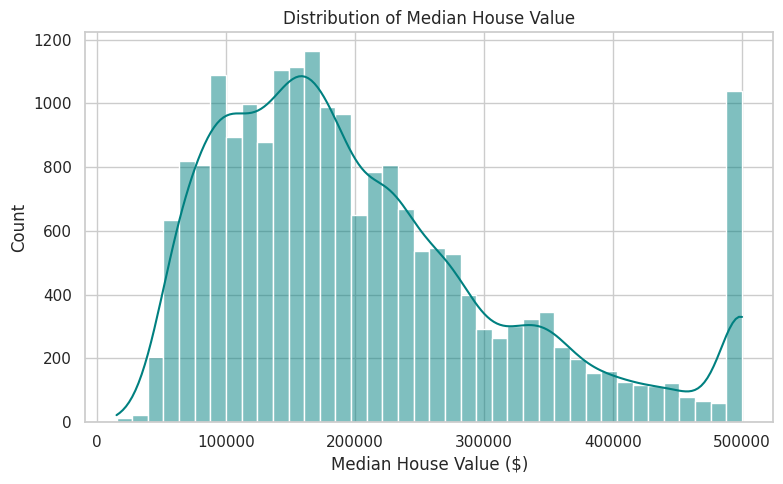

In [17]:
fig, ax = plt.subplots()
sns.histplot(df["median_house_value"], bins=40, kde=True, color="teal", ax=ax)
ax.set_title("Distribution of Median House Value")
ax.set_xlabel("Median House Value ($)")
plt.tight_layout()
plt.show()


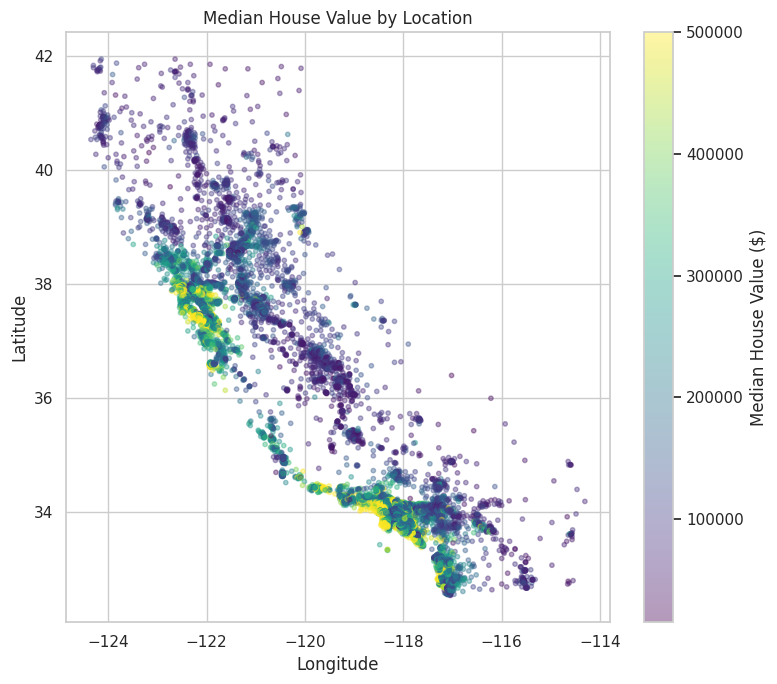

In [18]:
# Classic CA housing geographic scatter: location colored by price
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(df["longitude"], df["latitude"], c=df["median_house_value"],
                 cmap="viridis", alpha=0.4, s=10)
plt.colorbar(sc, ax=ax, label="Median House Value ($)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Median House Value by Location")
plt.tight_layout()
plt.show()


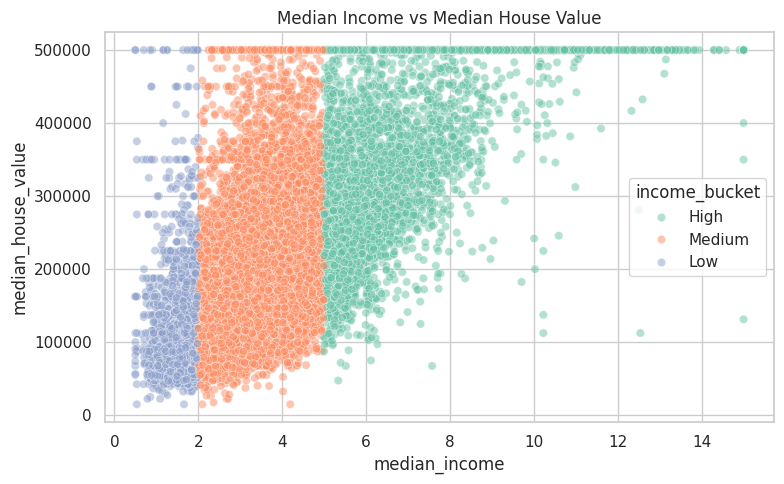

In [19]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="median_income", y="median_house_value",
                 hue="income_bucket", alpha=0.5, ax=ax)
ax.set_title("Median Income vs Median House Value")
plt.tight_layout()
plt.show()


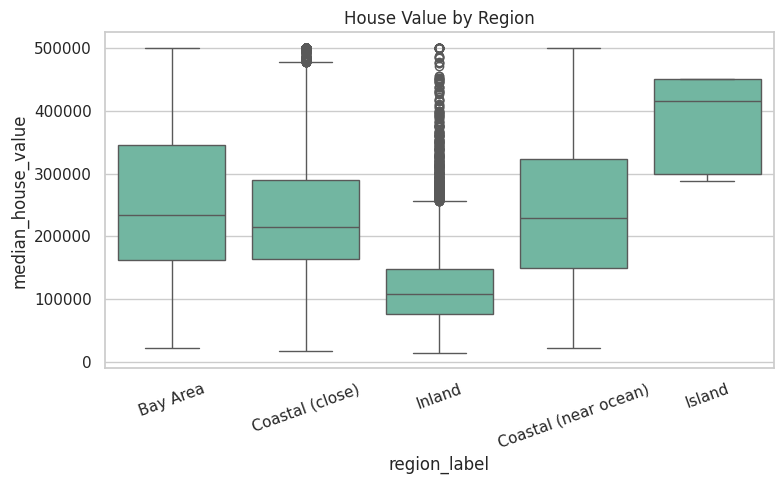

In [20]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="region_label", y="median_house_value", ax=ax)
ax.set_title("House Value by Region")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


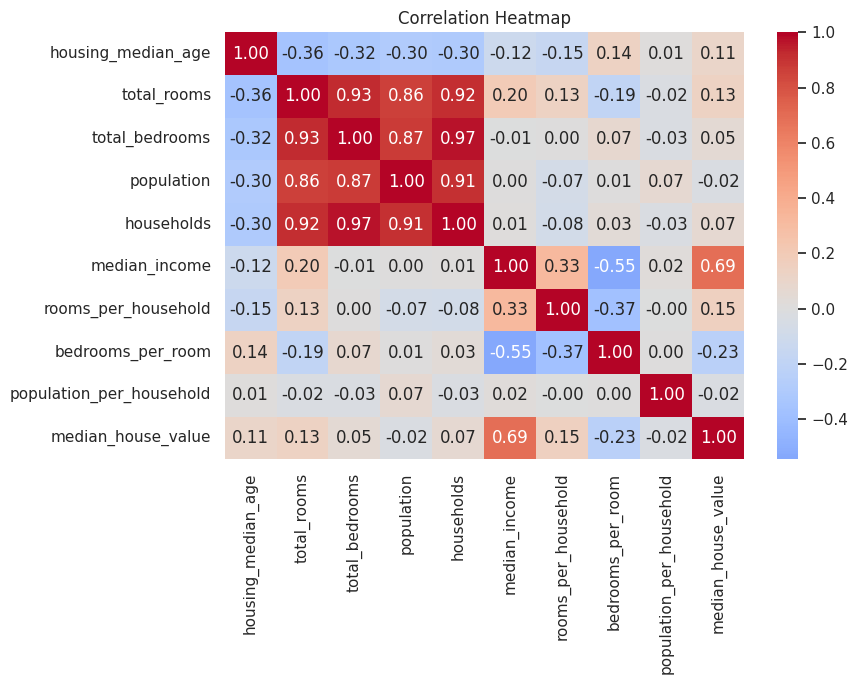

In [21]:
numeric_cols_for_corr = [
    "housing_median_age", "total_rooms", "total_bedrooms", "population",
    "households", "median_income", "rooms_per_household",
    "bedrooms_per_room", "population_per_household", "median_house_value",
]
corr = df[numeric_cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


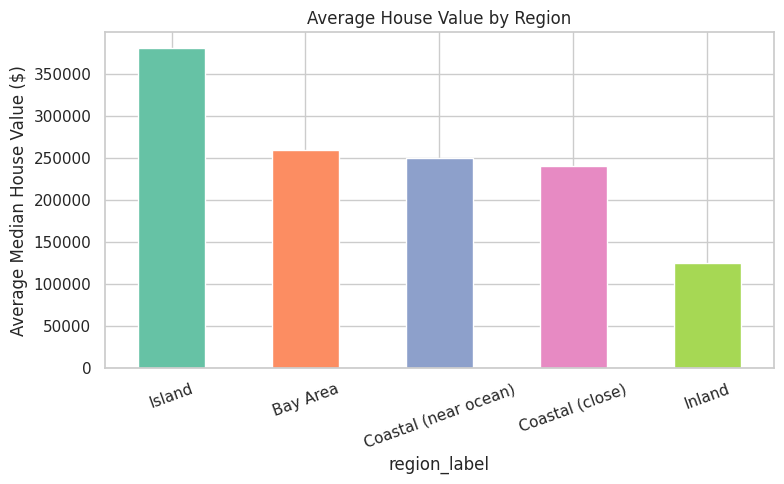

In [22]:
fig, ax = plt.subplots()
region_summary["avg_value"].plot(kind="bar", color=sns.color_palette("Set2"), ax=ax)
ax.set_title("Average House Value by Region")
ax.set_ylabel("Average Median House Value ($)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 8. Summary

In [23]:
feature, corr_value = analyzer.strongest_correlate()
print("Key insights")
print("-" * 40)
print(f"Number of districts analyzed   : {len(df)}")
print(f"Average median house value     : ${analyzer.average_value:,.2f}")
print(f"Strongest correlate of value   : {feature} (r = {corr_value})")
print(f"Highest-value region           : {region_summary['avg_value'].idxmax()}")
print(f"Price tier distribution        : {df['price_tier'].value_counts().to_dict()}")


Key insights
----------------------------------------
Number of districts analyzed   : 20640
Average median house value     : $206,855.82
Strongest correlate of value   : median_income (r = 0.688)
Highest-value region           : Island
Price tier distribution        : {'Affordable': 7556, 'Mid': 7255, 'High': 4058, 'Luxury': 1771}
